Historical Sales Data Injetion

In [2]:
#dataset used here is retail sales forecasting for sales prediction with linear regression
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data=pd.read_csv(r"C:\Users\Jasmine Rahaman\Desktop\vscode\jasmine\DataScienceProjects\mock_kaggle.csv")
df=pd.DataFrame(data)

Data preprocessing and feature engineering

In [10]:
data=pd.read_csv(r"C:\Users\Jasmine Rahaman\Desktop\vscode\jasmine\DataScienceProjects\mock_kaggle.csv")
#print("Shape of the dataset\n")
data.shape    #gives the number of rows and columns

#print("Converting the data into dataframe through pandas\n")
df=pd.DataFrame(data)

df.head()

print(df.info())   #describing the data

df.isnull().sum()  #to get the count of any null values, 0 null values found in any column

df.describe()

#df['date']=pd.to_datetime(df['date'],dayfirst=True)      #change the date format to day-month-year
df['date']=pd.to_datetime(df['date'],format='%d-%m-%Y')   #change date to datetime format
df['month']=df['date'].dt.month                           
df['day_of_week']=df['date'].dt.dayofweek

#creates lag and moving average feature
df['sales_lag1']=df['sale'].shift(1)
df['sales_ma7']=df['sale'].rolling(7).mean()

df=df.dropna()
df.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    937 non-null    object 
 1   sale    937 non-null    int64  
 2   stock   937 non-null    int64  
 3   price   937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB
None


,date,sale,stock,price,month,day_of_week,sales_lag1,sales_ma7
6,2014-01-07,179,4329,1.29,1,1,145.0,91.714286
7,2014-01-08,321,4104,1.29,1,2,179.0,137.571429
8,2014-01-09,125,4459,1.09,1,3,321.0,145.428571
9,2014-01-10,88,5043,1.09,1,4,125.0,149.571429
10,2014-01-11,188,5239,1.09,1,5,88.0,163.142857
11,2014-01-12,121,5118,1.09,1,6,188.0,166.714286
12,2014-01-13,134,4984,1.09,1,0,121.0,165.142857
13,2014-01-14,80,4904,1.09,1,1,134.0,151.000000
14,2014-01-15,82,4822,1.09,1,2,80.0,116.857143
15,2014-01-16,94,4728,1.19,1,3,82.0,112.428571


Trend and seasonality Analysis

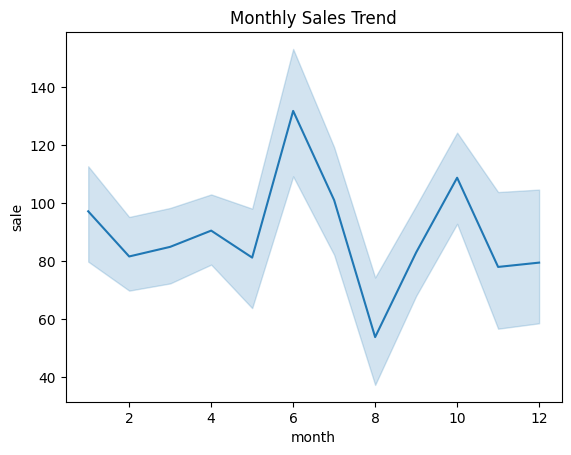

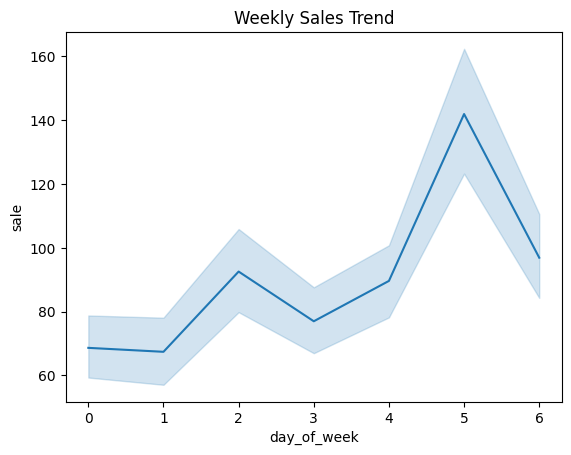

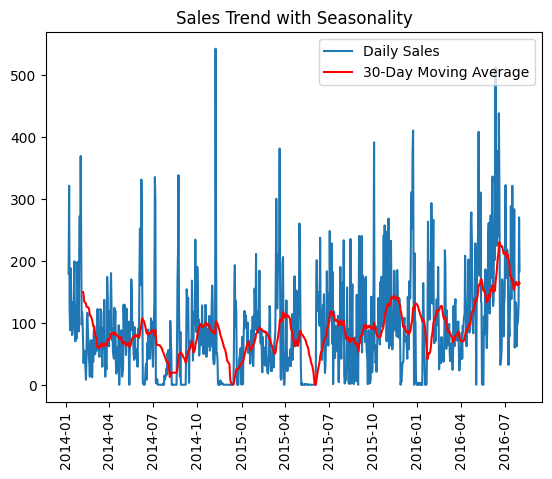

In [13]:
# Monthly sales trend
sns.lineplot(x='month', y='sale', data=df)
plt.title("Monthly Sales Trend")
plt.show()

# Weekly sales trend
sns.lineplot(x='day_of_week', y='sale', data=df)
plt.title("Weekly Sales Trend")
plt.show()

df['sales_ma30'] = df['sale'].rolling(30).mean()
plt.plot(df['date'], df['sale'], label="Daily Sales")
plt.plot(df['date'], df['sales_ma30'], label="30-Day Moving Average", color="red")
plt.xticks(rotation=90)
plt.legend()
plt.title("Sales Trend with Seasonality")
plt.show()


Train-Test split

In [14]:
train_size=int(len(df)*0.8)
train=df.iloc[:train_size].copy()
test=df.iloc[train_size:].copy()

train.loc[:,'date_ordinal']=train['date'].map(lambda x: x.toordinal())
test.loc[:,'date_ordinal']=test['date'].map(lambda x: x.toordinal())

features=['date_ordinal','stock','price','month','day_of_week','sales_ma7','sales_lag1']
X_train=train[features]
y_train=train['sale']
X_test=test[features]
y_test=test['sale']


Sales Forecasting using Machine Learning

In [16]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


MAE: 46.5143906790191
RMSE: 62.448192000959246
R2: 0.5153693215095645


Model Prediction Evaluation

In [17]:
print("MAE:",mean_absolute_error(y_test, y_pred))
mse=mean_squared_error(y_test, y_pred)
rmse=mse**0.5
print("RMSE:",rmse)
print("R2:",r2_score(y_test,y_pred))


MAE: 46.5143906790191
RMSE: 62.448192000959246
R2: 0.5153693215095645


Forecast Visualization and Interpretation

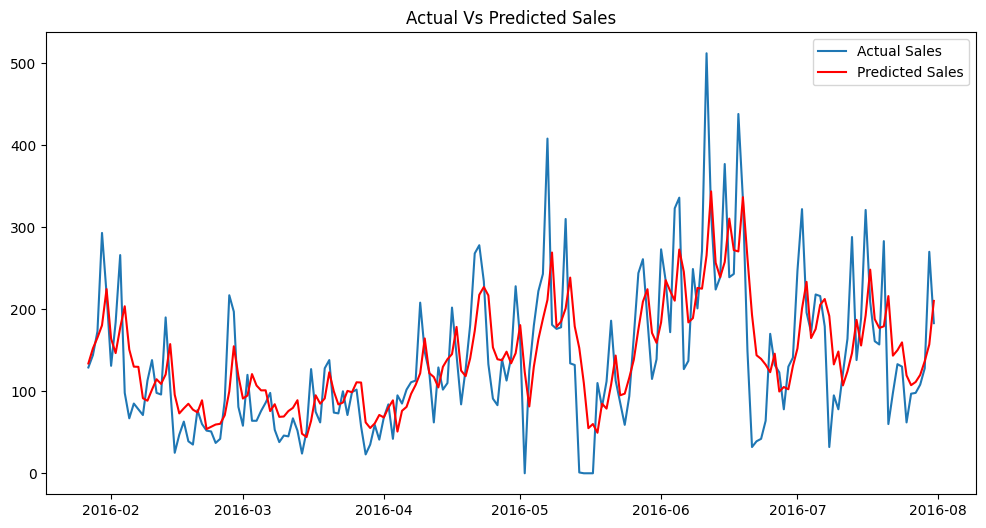

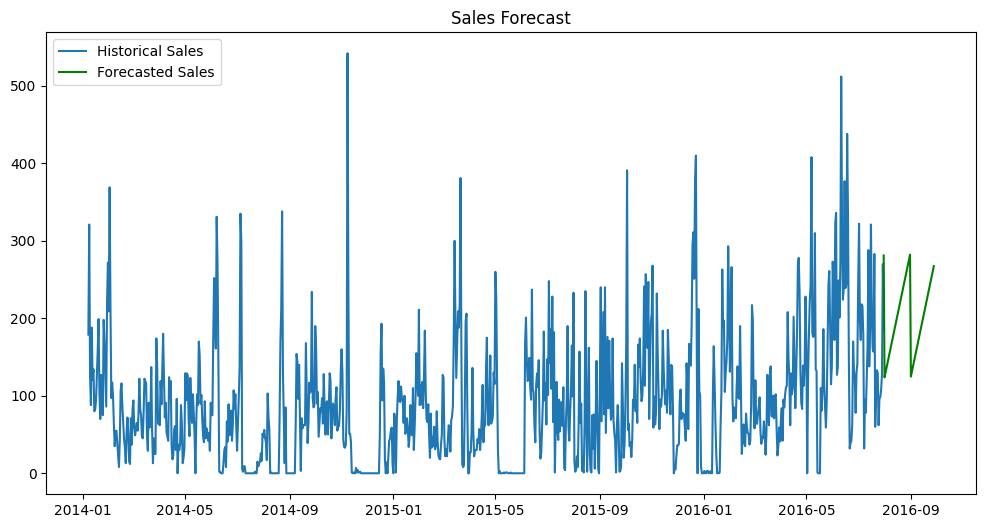

In [19]:
#actual vs predicted graph
plt.figure(figsize=(12,6))
plt.plot(test['date'],y_test,label='Actual Sales')
plt.plot(test['date'],y_pred,label='Predicted Sales',color='red')
plt.legend()
plt.title("Actual Vs Predicted Sales")
plt.show()

# Generate future dates (next 30 days)
future_dates = pd.date_range(df['date'].max(), periods=60, freq='D')
future_ordinals = future_dates.map(lambda x: x.toordinal()).values

# Assume average stock/price for forecast
future_stock = np.full((60,), df['stock'].mean())
future_price = np.full((60,), df['price'].mean())
future_month = future_dates.month
future_dayofmonth = future_dates.day
future_ma7 = np.full((60,), df['sales_ma7'].mean())
future_lag1 = np.full((60,), df['sale'].iloc[-1])  # last known sale

# Build future feature set
future_X = pd.DataFrame({
    'date_ordinal': future_ordinals,
    'stock': future_stock,
    'price': future_price,
    'month': future_month,
    'day_of_week': future_dayofmonth,
    'sales_ma7': future_ma7,
    'sales_lag1': future_lag1
})

# Predict future sales
future_preds = model.predict(future_X)
forecast = pd.DataFrame({"date": future_dates, "predicted_sales": future_preds})
forecast['predicted_revenue'] = forecast['predicted_sales'] * df['price'].mean()

#print(forecast.head())

# Plot forecast
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['sale'], label="Historical Sales")
plt.plot(forecast['date'], forecast['predicted_sales'], label="Forecasted Sales", color='green')
plt.legend()
plt.title("Sales Forecast")
plt.show()

Business-Oriented Insights


Inventory Planning: Forecasted peaks suggest when to stock more items.

Revenue Prediction: Multiplying forecasted sales by average price gives expected revenue.

Marketing Strategy: Seasonal dips highlight periods where promotions may be needed.

Decision Support: RMSE and R² indicate model reliability, guiding confidence in forecasts.